# Legacy Routing vs Smart Flooding Comparison
## Analysis of 4-Node Simulation Results

This notebook compares Distance Vector (DV) Routing and Smart Flooding performance across multiple simulation runs.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 10

## Load Data

In [17]:
# Read summary CSV
df = pd.read_csv('summary.csv')

# Display first few rows
print(f"Total records: {len(df)}")
print(f"\nRouting types: {df['Routing Type'].value_counts().to_dict()}")
df.head()

Total records: 20

Routing types: {'Flooding': 10, 'Routing': 10}


,Filename,Routing Type,Timestamp,Total Network Energy (J),Average PDR (%),Avg TX per Delivered Packet,Forwarding Overhead Ratio
0,LEGACY_Flooding_20260223_122253.txt,Flooding,20260223_122253,11823.316,65.00,139.30,131.45
1,LEGACY_Flooding_20260223_122602.txt,Flooding,20260223_122602,11810.580,63.75,139.87,130.95
2,LEGACY_Flooding_20260223_122852.txt,Flooding,20260223_122852,11781.390,55.75,157.53,129.44
3,LEGACY_Flooding_20260223_131855.txt,Flooding,20260223_131855,8835.298,48.00,131.20,97.59
4,LEGACY_Flooding_20260223_123142.txt,Flooding,20260223_123142,11796.401,71.00,120.73,130.23


## Prepare Data for Plotting

In [18]:
# Separate routing and flooding data
routing_df = df[df['Routing Type'] == 'Routing'].reset_index(drop=True)
flooding_df = df[df['Routing Type'] == 'Flooding'].reset_index(drop=True)

# Add run number (1-indexed)
routing_df['Run'] = range(1, len(routing_df) + 1)
flooding_df['Run'] = range(1, len(flooding_df) + 1)

# Calculate averages
routing_avg = {
    'energy': routing_df['Total Network Energy (J)'].astype(float).mean(),
    'pdr': routing_df['Average PDR (%)'].astype(float).mean(),
    'tx_per_delivered': routing_df['Avg TX per Delivered Packet'].astype(float).mean(),
    'overhead': routing_df['Forwarding Overhead Ratio'].astype(float).mean()
}

flooding_avg = {
    'energy': flooding_df['Total Network Energy (J)'].astype(float).mean(),
    'pdr': flooding_df['Average PDR (%)'].astype(float).mean(),
    'tx_per_delivered': flooding_df['Avg TX per Delivered Packet'].astype(float).mean(),
    'overhead': flooding_df['Forwarding Overhead Ratio'].astype(float).mean()
}

print("\n=== ROUTING AVERAGES ===")
for key, val in routing_avg.items():
    print(f"{key}: {val:.2f}")

print("\n=== FLOODING AVERAGES ===")
for key, val in flooding_avg.items():
    print(f"{key}: {val:.2f}")


=== ROUTING AVERAGES ===
energy: 4025.69
pdr: 77.62
tx_per_delivered: 8.44
overhead: 14.75

=== FLOODING AVERAGES ===
energy: 10837.81
pdr: 62.40
tx_per_delivered: 130.23
overhead: 120.68


## Comparison Plots
### Scatter plots with average lines (dashed)

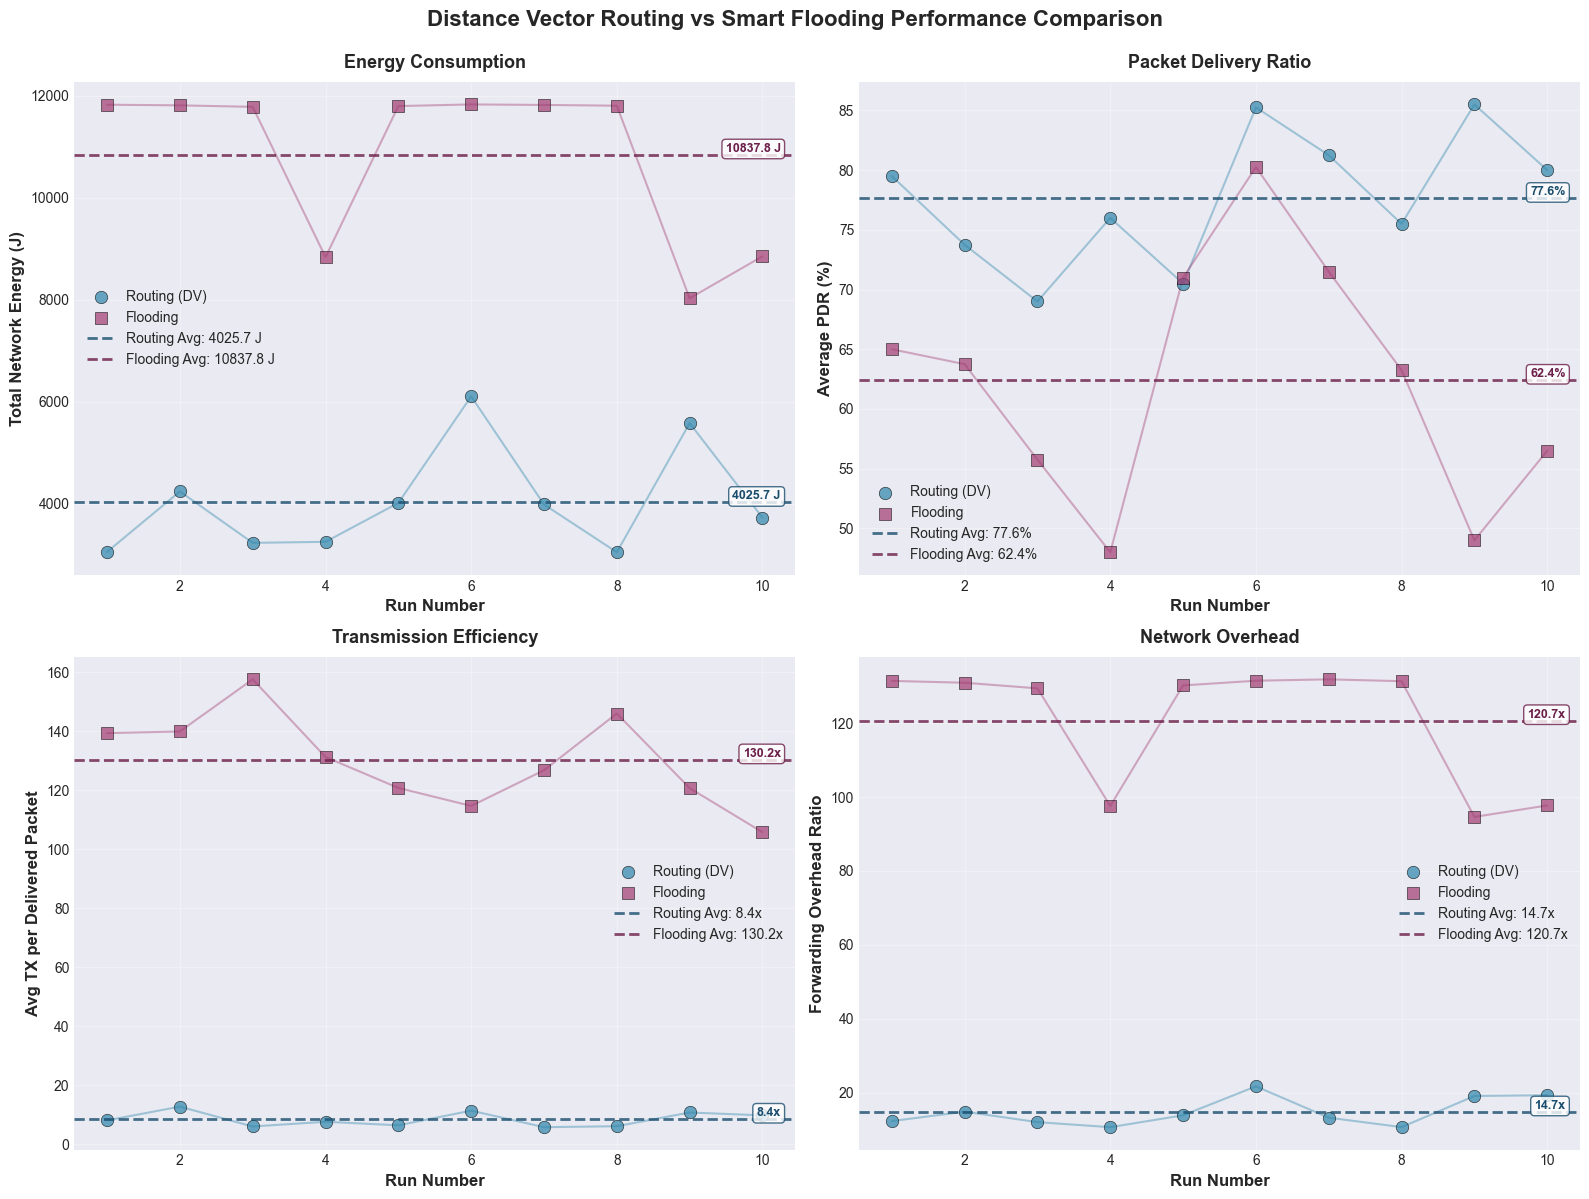

✅ Plots saved as 'routing_vs_flooding_comparison.png'


In [19]:
# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Distance Vector Routing vs Smart Flooding Performance Comparison', 
             fontsize=16, fontweight='bold', y=0.995)

# Colors
routing_color = '#2E86AB'  # Blue
flooding_color = '#A23B72'  # Purple
routing_avg_color = '#1a4d6d'  # Dark blue
flooding_avg_color = '#6b1e47'  # Dark purple

# Plot 1: Total Energy Consumed vs Number of Runs
ax1 = axes[0, 0]
ax1.plot(routing_df['Run'], routing_df['Total Network Energy (J)'].astype(float), 
         color=routing_color, alpha=0.4, linewidth=1.5, zorder=1)
ax1.scatter(routing_df['Run'], routing_df['Total Network Energy (J)'].astype(float), 
           s=80, alpha=0.7, c=routing_color, label='Routing (DV)', marker='o', edgecolors='black', linewidths=0.5, zorder=2)
ax1.plot(flooding_df['Run'], flooding_df['Total Network Energy (J)'].astype(float), 
         color=flooding_color, alpha=0.4, linewidth=1.5, zorder=1)
ax1.scatter(flooding_df['Run'], flooding_df['Total Network Energy (J)'].astype(float), 
           s=80, alpha=0.7, c=flooding_color, label='Flooding', marker='s', edgecolors='black', linewidths=0.5, zorder=2)

# Add average lines
ax1.axhline(y=routing_avg['energy'], color=routing_avg_color, linestyle='--', linewidth=2, 
           label=f'Routing Avg: {routing_avg["energy"]:.1f} J', alpha=0.8)
ax1.axhline(y=flooding_avg['energy'], color=flooding_avg_color, linestyle='--', linewidth=2, 
           label=f'Flooding Avg: {flooding_avg["energy"]:.1f} J', alpha=0.8)

# Add text labels for average values
ax1.text(0.98, routing_avg['energy'], f'{routing_avg["energy"]:.1f} J', 
         transform=ax1.get_yaxis_transform(), ha='right', va='bottom', 
         fontsize=9, color=routing_avg_color, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=routing_avg_color))
ax1.text(0.98, flooding_avg['energy'], f'{flooding_avg["energy"]:.1f} J', 
         transform=ax1.get_yaxis_transform(), ha='right', va='bottom', 
         fontsize=9, color=flooding_avg_color, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=flooding_avg_color))

ax1.set_xlabel('Run Number', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Network Energy (J)', fontsize=12, fontweight='bold')
ax1.set_title('Energy Consumption', fontsize=13, fontweight='bold', pad=10)
ax1.legend(loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# Plot 2: Average PDR vs Number of Runs
ax2 = axes[0, 1]
ax2.plot(routing_df['Run'], routing_df['Average PDR (%)'].astype(float), 
         color=routing_color, alpha=0.4, linewidth=1.5, zorder=1)
ax2.scatter(routing_df['Run'], routing_df['Average PDR (%)'].astype(float), 
           s=80, alpha=0.7, c=routing_color, label='Routing (DV)', marker='o', edgecolors='black', linewidths=0.5, zorder=2)
ax2.plot(flooding_df['Run'], flooding_df['Average PDR (%)'].astype(float), 
         color=flooding_color, alpha=0.4, linewidth=1.5, zorder=1)
ax2.scatter(flooding_df['Run'], flooding_df['Average PDR (%)'].astype(float), 
           s=80, alpha=0.7, c=flooding_color, label='Flooding', marker='s', edgecolors='black', linewidths=0.5, zorder=2)

# Add average lines
ax2.axhline(y=routing_avg['pdr'], color=routing_avg_color, linestyle='--', linewidth=2, 
           label=f'Routing Avg: {routing_avg["pdr"]:.1f}%', alpha=0.8)
ax2.axhline(y=flooding_avg['pdr'], color=flooding_avg_color, linestyle='--', linewidth=2, 
           label=f'Flooding Avg: {flooding_avg["pdr"]:.1f}%', alpha=0.8)

# Add text labels for average values
ax2.text(0.98, routing_avg['pdr'], f'{routing_avg["pdr"]:.1f}%', 
         transform=ax2.get_yaxis_transform(), ha='right', va='bottom', 
         fontsize=9, color=routing_avg_color, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=routing_avg_color))
ax2.text(0.98, flooding_avg['pdr'], f'{flooding_avg["pdr"]:.1f}%', 
         transform=ax2.get_yaxis_transform(), ha='right', va='bottom', 
         fontsize=9, color=flooding_avg_color, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=flooding_avg_color))

ax2.set_xlabel('Run Number', fontsize=12, fontweight='bold')
ax2.set_ylabel('Average PDR (%)', fontsize=12, fontweight='bold')
ax2.set_title('Packet Delivery Ratio', fontsize=13, fontweight='bold', pad=10)
ax2.legend(loc='best', framealpha=0.9)
ax2.grid(True, alpha=0.3)

# Plot 3: Avg TX per Delivered Packet vs Number of Runs
ax3 = axes[1, 0]
ax3.plot(routing_df['Run'], routing_df['Avg TX per Delivered Packet'].astype(float), 
         color=routing_color, alpha=0.4, linewidth=1.5, zorder=1)
ax3.scatter(routing_df['Run'], routing_df['Avg TX per Delivered Packet'].astype(float), 
           s=80, alpha=0.7, c=routing_color, label='Routing (DV)', marker='o', edgecolors='black', linewidths=0.5, zorder=2)
ax3.plot(flooding_df['Run'], flooding_df['Avg TX per Delivered Packet'].astype(float), 
         color=flooding_color, alpha=0.4, linewidth=1.5, zorder=1)
ax3.scatter(flooding_df['Run'], flooding_df['Avg TX per Delivered Packet'].astype(float), 
           s=80, alpha=0.7, c=flooding_color, label='Flooding', marker='s', edgecolors='black', linewidths=0.5, zorder=2)

# Add average lines
ax3.axhline(y=routing_avg['tx_per_delivered'], color=routing_avg_color, linestyle='--', linewidth=2, 
           label=f'Routing Avg: {routing_avg["tx_per_delivered"]:.1f}x', alpha=0.8)
ax3.axhline(y=flooding_avg['tx_per_delivered'], color=flooding_avg_color, linestyle='--', linewidth=2, 
           label=f'Flooding Avg: {flooding_avg["tx_per_delivered"]:.1f}x', alpha=0.8)

# Add text labels for average values
ax3.text(0.98, routing_avg['tx_per_delivered'], f'{routing_avg["tx_per_delivered"]:.1f}x', 
         transform=ax3.get_yaxis_transform(), ha='right', va='bottom', 
         fontsize=9, color=routing_avg_color, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=routing_avg_color))
ax3.text(0.98, flooding_avg['tx_per_delivered'], f'{flooding_avg["tx_per_delivered"]:.1f}x', 
         transform=ax3.get_yaxis_transform(), ha='right', va='bottom', 
         fontsize=9, color=flooding_avg_color, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=flooding_avg_color))

ax3.set_xlabel('Run Number', fontsize=12, fontweight='bold')
ax3.set_ylabel('Avg TX per Delivered Packet', fontsize=12, fontweight='bold')
ax3.set_title('Transmission Efficiency', fontsize=13, fontweight='bold', pad=10)
ax3.legend(loc='best', framealpha=0.9)
ax3.grid(True, alpha=0.3)

# Plot 4: Forwarding Overhead Ratio vs Number of Runs
ax4 = axes[1, 1]
ax4.plot(routing_df['Run'], routing_df['Forwarding Overhead Ratio'].astype(float), 
         color=routing_color, alpha=0.4, linewidth=1.5, zorder=1)
ax4.scatter(routing_df['Run'], routing_df['Forwarding Overhead Ratio'].astype(float), 
           s=80, alpha=0.7, c=routing_color, label='Routing (DV)', marker='o', edgecolors='black', linewidths=0.5, zorder=2)
ax4.plot(flooding_df['Run'], flooding_df['Forwarding Overhead Ratio'].astype(float), 
         color=flooding_color, alpha=0.4, linewidth=1.5, zorder=1)
ax4.scatter(flooding_df['Run'], flooding_df['Forwarding Overhead Ratio'].astype(float), 
           s=80, alpha=0.7, c=flooding_color, label='Flooding', marker='s', edgecolors='black', linewidths=0.5, zorder=2)

# Add average lines
ax4.axhline(y=routing_avg['overhead'], color=routing_avg_color, linestyle='--', linewidth=2, 
           label=f'Routing Avg: {routing_avg["overhead"]:.1f}x', alpha=0.8)
ax4.axhline(y=flooding_avg['overhead'], color=flooding_avg_color, linestyle='--', linewidth=2, 
           label=f'Flooding Avg: {flooding_avg["overhead"]:.1f}x', alpha=0.8)

# Add text labels for average values
ax4.text(0.98, routing_avg['overhead'], f'{routing_avg["overhead"]:.1f}x', 
         transform=ax4.get_yaxis_transform(), ha='right', va='bottom', 
         fontsize=9, color=routing_avg_color, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=routing_avg_color))
ax4.text(0.98, flooding_avg['overhead'], f'{flooding_avg["overhead"]:.1f}x', 
         transform=ax4.get_yaxis_transform(), ha='right', va='bottom', 
         fontsize=9, color=flooding_avg_color, fontweight='bold', 
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=flooding_avg_color))

ax4.set_xlabel('Run Number', fontsize=12, fontweight='bold')
ax4.set_ylabel('Forwarding Overhead Ratio', fontsize=12, fontweight='bold')
ax4.set_title('Network Overhead', fontsize=13, fontweight='bold', pad=10)
ax4.legend(loc='best', framealpha=0.9)
ax4.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.savefig('routing_vs_flooding_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plots saved as 'routing_vs_flooding_comparison.png'")

## Bar Chart Comparison
### Average values for Routing (DV) vs Smart Flooding

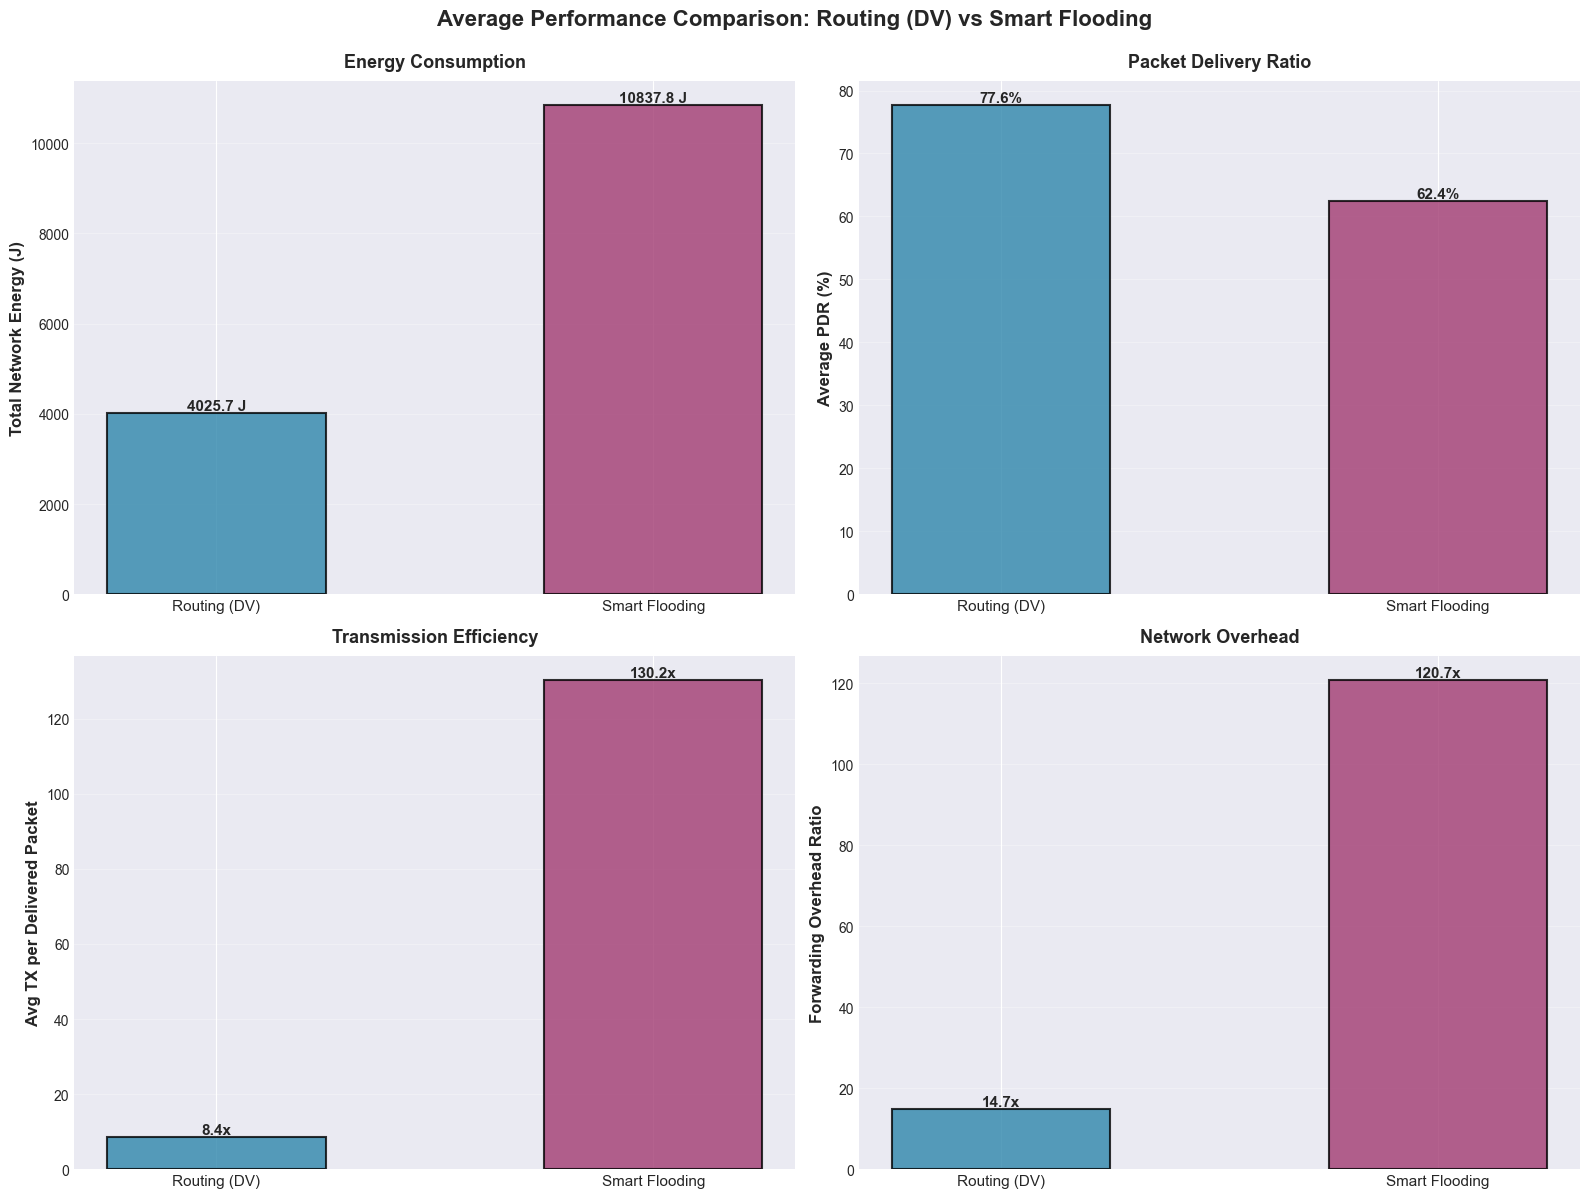

✅ Bar charts saved as 'routing_vs_flooding_bar_comparison.png'


In [20]:
# Create 2x2 bar chart figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Average Performance Comparison: Routing (DV) vs Smart Flooding', 
             fontsize=16, fontweight='bold', y=0.995)

# Colors
routing_bar_color = '#2E86AB'  # Blue
flooding_bar_color = '#A23B72'  # Purple
bar_width = 0.5

# X positions for bars
x_pos = [1, 2]
x_labels = ['Routing (DV)', 'Smart Flooding']

# Plot 1: Total Energy Consumed
ax1 = axes[0, 0]
energy_values = [routing_avg['energy'], flooding_avg['energy']]
bars1 = ax1.bar(x_pos, energy_values, width=bar_width, 
               color=[routing_bar_color, flooding_bar_color],
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars1, energy_values)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f} J',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel('Total Network Energy (J)', fontsize=12, fontweight='bold')
ax1.set_title('Energy Consumption', fontsize=13, fontweight='bold', pad=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Average PDR
ax2 = axes[0, 1]
pdr_values = [routing_avg['pdr'], flooding_avg['pdr']]
bars2 = ax2.bar(x_pos, pdr_values, width=bar_width,
               color=[routing_bar_color, flooding_bar_color],
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars2, pdr_values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Average PDR (%)', fontsize=12, fontweight='bold')
ax2.set_title('Packet Delivery Ratio', fontsize=13, fontweight='bold', pad=10)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels, fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Avg TX per Delivered Packet
ax3 = axes[1, 0]
tx_values = [routing_avg['tx_per_delivered'], flooding_avg['tx_per_delivered']]
bars3 = ax3.bar(x_pos, tx_values, width=bar_width,
               color=[routing_bar_color, flooding_bar_color],
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars3, tx_values)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}x',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax3.set_ylabel('Avg TX per Delivered Packet', fontsize=12, fontweight='bold')
ax3.set_title('Transmission Efficiency', fontsize=13, fontweight='bold', pad=10)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(x_labels, fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Forwarding Overhead Ratio
ax4 = axes[1, 1]
overhead_values = [routing_avg['overhead'], flooding_avg['overhead']]
bars4 = ax4.bar(x_pos, overhead_values, width=bar_width,
               color=[routing_bar_color, flooding_bar_color],
               edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars4, overhead_values)):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}x',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax4.set_ylabel('Forwarding Overhead Ratio', fontsize=12, fontweight='bold')
ax4.set_title('Network Overhead', fontsize=13, fontweight='bold', pad=10)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(x_labels, fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')

# Adjust layout
plt.tight_layout()
plt.savefig('routing_vs_flooding_bar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Bar charts saved as 'routing_vs_flooding_bar_comparison.png'")

## Statistical Summary

In [21]:
# Create comparison table
comparison = pd.DataFrame({
    'Metric': [
        'Total Network Energy (J)',
        'Average PDR (%)',
        'Avg TX per Delivered Packet',
        'Forwarding Overhead Ratio'
    ],
    'Routing (DV) Mean': [
        f"{routing_avg['energy']:.2f}",
        f"{routing_avg['pdr']:.2f}",
        f"{routing_avg['tx_per_delivered']:.2f}",
        f"{routing_avg['overhead']:.2f}"
    ],
    'Routing (DV) Std': [
        f"{routing_df['Total Network Energy (J)'].astype(float).std():.2f}",
        f"{routing_df['Average PDR (%)'].astype(float).std():.2f}",
        f"{routing_df['Avg TX per Delivered Packet'].astype(float).std():.2f}",
        f"{routing_df['Forwarding Overhead Ratio'].astype(float).std():.2f}"
    ],
    'Flooding Mean': [
        f"{flooding_avg['energy']:.2f}",
        f"{flooding_avg['pdr']:.2f}",
        f"{flooding_avg['tx_per_delivered']:.2f}",
        f"{flooding_avg['overhead']:.2f}"
    ],
    'Flooding Std': [
        f"{flooding_df['Total Network Energy (J)'].astype(float).std():.2f}",
        f"{flooding_df['Average PDR (%)'].astype(float).std():.2f}",
        f"{flooding_df['Avg TX per Delivered Packet'].astype(float).std():.2f}",
        f"{flooding_df['Forwarding Overhead Ratio'].astype(float).std():.2f}"
    ]
})

print("\n" + "="*80)
print("STATISTICAL COMPARISON: ROUTING (DV) vs FLOODING")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)

# Calculate improvement percentages
print("\n" + "="*80)
print("ROUTING IMPROVEMENT OVER FLOODING")
print("="*80)
energy_improvement = ((flooding_avg['energy'] - routing_avg['energy']) / flooding_avg['energy']) * 100
pdr_improvement = ((routing_avg['pdr'] - flooding_avg['pdr']) / flooding_avg['pdr']) * 100
tx_improvement = ((flooding_avg['tx_per_delivered'] - routing_avg['tx_per_delivered']) / flooding_avg['tx_per_delivered']) * 100
overhead_improvement = ((flooding_avg['overhead'] - routing_avg['overhead']) / flooding_avg['overhead']) * 100

print(f"Energy Reduction: {energy_improvement:.1f}%")
print(f"PDR Improvement: {pdr_improvement:+.1f}%")
print(f"TX Efficiency Improvement: {tx_improvement:.1f}%")
print(f"Overhead Reduction: {overhead_improvement:.1f}%")
print("="*80)


STATISTICAL COMPARISON: ROUTING (DV) vs FLOODING
                     Metric Routing (DV) Mean Routing (DV) Std Flooding Mean Flooding Std
   Total Network Energy (J)           4025.69          1053.90      10837.81      1579.51
            Average PDR (%)             77.62             5.67         62.40        10.28
Avg TX per Delivered Packet              8.44             2.53        130.23        15.66
  Forwarding Overhead Ratio             14.75             3.92        120.68        16.61

ROUTING IMPROVEMENT OVER FLOODING
Energy Reduction: 62.9%
PDR Improvement: +24.4%
TX Efficiency Improvement: 93.5%
Overhead Reduction: 87.8%
